In [5]:
import pandas as pd
import numpy as np

# Set seed agar hasil random tetap konsisten setiap kali dijalankan
np.random.seed(42)

# Menentukan jumlah data
n = 1000

# 1. Generate Tanggal (Periode 1 Desember - 31 Desember 2026)
tanggal = pd.date_range(start='2026-12-01', end='2026-12-31')
tanggal_transaksi = np.random.choice(tanggal, size=n)

# 2. Generate Wilayah dengan probabilitas realistis (Jakarta lebih padat)
wilayah_list = ['Jakarta', 'Bandung', 'Surabaya', 'Medan', 'Makassar']
probabilitas = [0.4, 0.25, 0.2, 0.1, 0.05]
wilayah = np.random.choice(wilayah_list, size=n, p=probabilitas)

# 3. Generate Diskon (Hanya berlaku untuk event 12.12)
is_diskon = (pd.DatetimeIndex(tanggal_transaksi).day == 12)
diskon_persen = np.where(is_diskon, 20, 0)

# 4. Generate Pendapatan (Distribusi Normal)
# Rata-rata dasar Rp 500.000 dengan standar deviasi Rp 150.000
base_pendapatan = np.random.normal(loc=500000, scale=150000, size=n)

# Simulasi perilaku konsumen: Pendapatan melonjak 1.5x - 2x saat diskon 12.12
efek_diskon = np.where(is_diskon, np.random.uniform(1.5, 2.0, size=n), 1)
pendapatan = base_pendapatan * efek_diskon

# 5. Injeksi nilai NaN secara acak (sekitar 5% data hilang untuk latihan cleaning)
nan_indices = np.random.choice(n, size=int(n * 0.05), replace=False)
pendapatan[nan_indices] = np.nan

# 6. Susun menjadi Pandas DataFrame
df = pd.DataFrame({
    'transaksi_id': [f'T{str(i).zfill(4)}' for i in range(1, n+1)],
    'tanggal': tanggal_transaksi,
    'wilayah': wilayah,
    'pendapatan': pendapatan,
    'diskon_persen': diskon_persen
})

# Merapikan nilai pendapatan agar tidak ada angka desimal
df['pendapatan'] = df['pendapatan'].round()

# Menampilkan pratinjau data
print("Pratinjau Dataset:")
print(df.head(10))

print("\n--- Ringkasan Dataset ---")
print(f"Total baris: {len(df)}")
print(f"Jumlah baris dengan nilai NaN pada kolom pendapatan: {df['pendapatan'].isna().sum()}")

Pratinjau Dataset:
  transaksi_id    tanggal   wilayah  pendapatan  diskon_persen
0        T0001 2026-12-07   Jakarta    471665.0              0
1        T0002 2026-12-20  Makassar    582961.0              0
2        T0003 2026-12-29  Surabaya    494947.0              0
3        T0004 2026-12-15  Surabaya    357448.0              0
4        T0005 2026-12-11   Bandung    369414.0              0
5        T0006 2026-12-08   Bandung    352359.0              0
6        T0007 2026-12-29   Jakarta    645635.0              0
7        T0008 2026-12-21   Jakarta    407383.0              0
8        T0009 2026-12-07     Medan    213185.0              0
9        T0010 2026-12-26  Surabaya    559526.0              0

--- Ringkasan Dataset ---
Total baris: 1000
Jumlah baris dengan nilai NaN pada kolom pendapatan: 50


In [6]:
#Mengubah kolom 'tanggal' menjadi format datetime
df['tanggal'] = pd.to_datetime(df['tanggal'])

#Mengisi nilai NaN pada 'pendapatan' dengan rata-rata pendapatan per 'wilayah'
df['pendapatan'] = df['pendapatan'].fillna(df.groupby('wilayah')['pendapatan'].transform('mean'))

#Merapikan nilai pendapatan
df['pendapatan'] = df['pendapatan'].round()

#Mengecek apakah ada masih ada nilai kosong
print("Jumlah nilai kosong saat ini : ")
print(df.isna().sum())

Jumlah nilai kosong saat ini : 
transaksi_id     0
tanggal          0
wilayah          0
pendapatan       0
diskon_persen    0
dtype: int64


In [9]:
#Perbandingan rata-rata pendapatan keseluruhan (Normal vs Diskon)
#Mengelompokkan data berdasarkan presentase diskon
ringkasan_diskon = df.groupby('diskon_persen')['pendapatan'].mean().round()
print("Rata-rata pendapatan keseluruhan")
print(ringkasan_diskon)
print("\n" + "="*40 + "\n")

#Performa diskon di setiap wilayah
#Menggunakan dua kunci groupby dan unstack() agar tampilannya menyerupai tabel pivot (Excel)
ringkasan_wilayah = df.groupby(['wilayah','diskon_persen'])['pendapatan'].mean().unstack().round()

#Mengubah nama kolom agar lebih mudah dibaca
ringkasan_wilayah.columns = ['Hari Normal (0%)', 'Hari Diskon (20%)']

#Menghitung selisih kenaikan
ringkasan_wilayah['Kenaikan (Rp)'] = ringkasan_wilayah['Hari Diskon (20%)'] - ringkasan_wilayah['Hari Normal (0%)']
print("Dampak Diskon per Wilayah: ")
print(ringkasan_wilayah.sort_values(by='Kenaikan (Rp)', ascending=False))


Rata-rata pendapatan keseluruhan
diskon_persen
0     498883.0
20    869361.0
Name: pendapatan, dtype: float64


Dampak Diskon per Wilayah: 
          Hari Normal (0%)  Hari Diskon (20%)  Kenaikan (Rp)
wilayah                                                     
Bandung           500256.0           919530.0       419274.0
Medan             489956.0           893475.0       403519.0
Jakarta           489941.0           875877.0       385936.0
Makassar          568113.0           950011.0       381898.0
Surabaya          504702.0           745999.0       241297.0


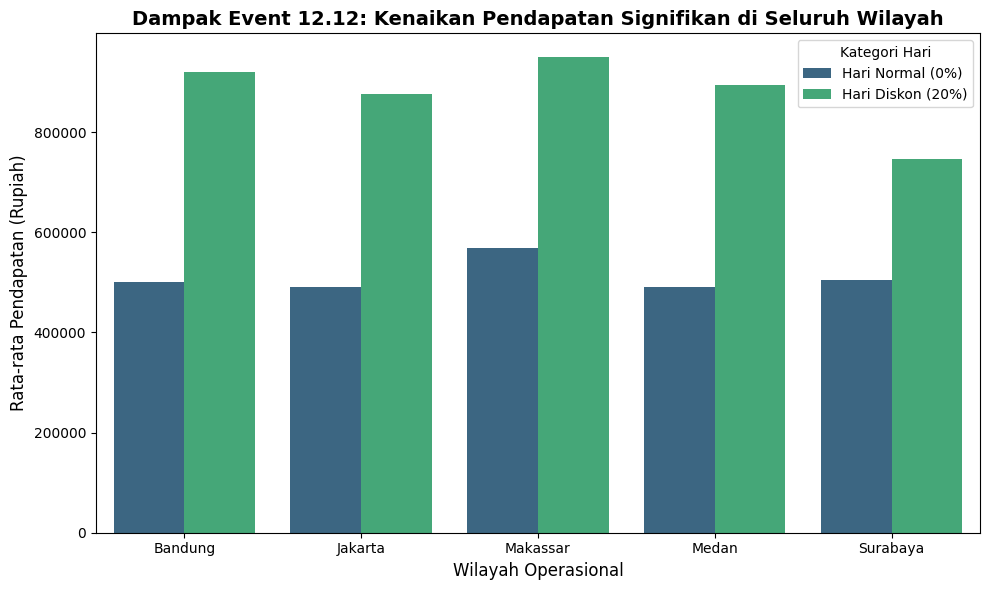

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

#Menyiapkan data untuk visualisasi
#reset index supaya kolom 'wilayah' kembali menjadi kolom biasa
df_viz = ringkasan_wilayah.reset_index()

#Mengubah format tabel (melt) agar seaborn mudah membacanya untuk grafik berdampingan
df_melt = df_viz.melt(id_vars='wilayah',
                      value_vars=['Hari Normal (0%)', 'Hari Diskon (20%)'],
                      var_name='Kategori Hari',
                      value_name='Pendapatan')

#Membuat visualisasi dengan seaborn
plt.figure(figsize=(10,6)) #Mengatur ukuran kanvas grafik

#Membuat Bar Chart
sns.barplot(data=df_melt, x = 'wilayah', y = 'Pendapatan', hue = 'Kategori Hari', palette='viridis')

#Menambahkan elemen bercerita (Storytelling)
plt.title('Dampak Event 12.12: Kenaikan Pendapatan Signifikan di Seluruh Wilayah', fontsize=14, fontweight='bold')
plt.xlabel('Wilayah Operasional', fontsize=12)
plt.ylabel('Rata-rata Pendapatan (Rupiah)', fontsize=12)

#Mengatur formal angka di sumbu y supaya tidak berformat sains (e.g., 1e6)
plt.ticklabel_format(style='plain', axis='y')

#Menampilkan grafik
plt.tight_layout()
plt.show()